# Preprocessing — ELEC3612 Assignment 1

This notebook loads the dataset, explores its structure, and defines 
the preprocessing pipeline used across all model notebooks. The pipeline 
handles missing value imputation, feature encoding, and scaling, and is 
always fitted after the train/test split to prevent data leakage.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('../data/aug_train.csv')

print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 5 rows:\n{df.head()}")

Shape: (19158, 14)

Data types:
enrollee_id                 int64
city                       object
city_development_index    float64
gender                     object
relevent_experience        object
enrolled_university        object
education_level            object
major_discipline           object
experience                 object
company_size               object
company_type               object
last_new_job               object
training_hours              int64
target                    float64
dtype: object

First 5 rows:
   enrollee_id      city  city_development_index gender  \
0         8949  city_103                   0.920   Male   
1        29725   city_40                   0.776   Male   
2        11561   city_21                   0.624    NaN   
3        33241  city_115                   0.789    NaN   
4          666  city_162                   0.767   Male   

       relevent_experience enrolled_university education_level  \
0  Has relevent experience       no_enroll

## Exploratory Data Analysis

First we look at the class balance and which columns have missing values. 
Both things directly affect decisions made later, the class imbalance 
means we need stratified splits, and the missing value percentages tell 
us how aggressively we need to impute.

In [4]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print("=== Missing Values ===")
print(missing_df[missing_df['Missing'] > 0].sort_values('Percentage', ascending=False))

# Target distribution
print("\n=== Target Distribution ===")
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True).round(3))

=== Missing Values ===
                     Missing  Percentage
company_type            6140   32.049274
company_size            5938   30.994885
gender                  4508   23.530640
major_discipline        2813   14.683161
education_level          460    2.401086
last_new_job             423    2.207955
enrolled_university      386    2.014824
experience                65    0.339284

=== Target Distribution ===
target
0.0    14381
1.0     4777
Name: count, dtype: int64
target
0.0    0.751
1.0    0.249
Name: proportion, dtype: float64


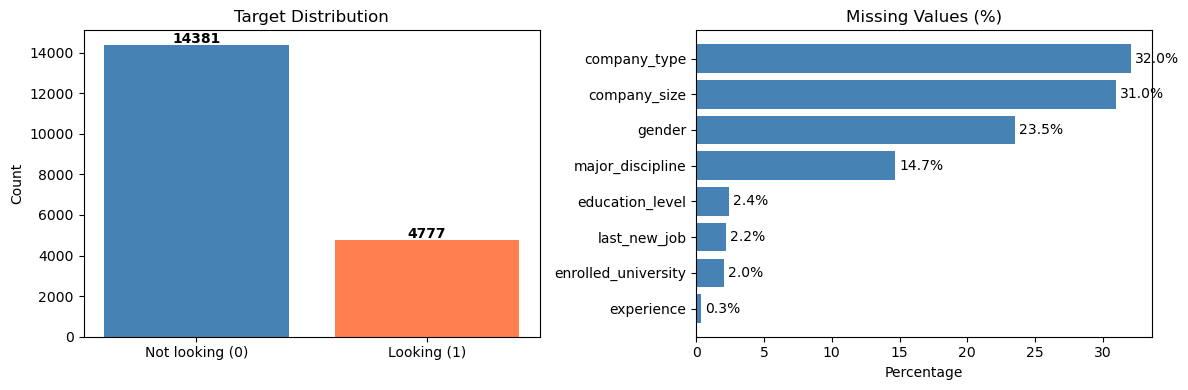

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target distribution
axes[0].bar(['Not looking (0)', 'Looking (1)'], 
            df['target'].value_counts().values,
            color=['steelblue', 'coral'])
axes[0].set_title('Target Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(df['target'].value_counts().values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Missing values
missing_cols = missing_df[missing_df['Missing'] > 0].sort_values('Percentage', ascending=True)
axes[1].barh(missing_cols.index, missing_cols['Percentage'], color='steelblue')
axes[1].set_title('Missing Values (%)')
axes[1].set_xlabel('Percentage')
for i, v in enumerate(missing_cols['Percentage']):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.savefig('../report/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Classification

We identify which columns need which treatment, numerical columns get 
median imputation and scaling, ordinal categoricals get ordinal encoding, 
and nominal categoricals get one-hot encoding.

In [8]:
# Drop enrollee_id (not a feature) and separate target
df = df.drop(columns=['enrollee_id'])

# Separate features and target
X = df.drop(columns=['target'])
y = df['target']

# Define column types
numerical_cols = ['city_development_index', 'training_hours']

ordinal_cols = ['experience', 'last_new_job']  # have a natural order

nominal_cols = ['city', 'gender', 'relevent_experience', 
                'enrolled_university', 'education_level',
                'major_discipline', 'company_size', 'company_type']

print(f"Numerical : {numerical_cols}")
print(f"Ordinal   : {ordinal_cols}")
print(f"Nominal   : {nominal_cols}")
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

Numerical : ['city_development_index', 'training_hours']
Ordinal   : ['experience', 'last_new_job']
Nominal   : ['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'company_size', 'company_type']

X shape: (19158, 12)
y shape: (19158,)


## Preprocessing Pipeline

We use a ColumnTransformer to apply different preprocessing steps to each 
column type. The full pipeline is fitted only on training data inside each 
experiment, ensuring no information from the test set leaks into training.

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

# Numerical: impute with median + scale
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Ordinal: impute with most frequent + ordinal encode
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Nominal: impute with most frequent + one-hot encode
nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine all
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_cols),
    ('ord', ordinal_pipeline, ordinal_cols),
    ('nom', nominal_pipeline, nominal_cols)
])

print("Preprocessor defined successfully")
print(preprocessor)

Preprocessor defined successfully
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['city_development_index', 'training_hours']),
                                ('ord',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['experience', 'last_new_job']),
                                ('nom',
                                 Pipeline(steps=[('imputer',
          

## Pipeline Verification

We run a quick check to confirm the pipeline works correctly 
on a sample split before using it across all model notebooks.

In [ ]:
from sklearn.model_selection import train_test_split

# Quick check with 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Fit only on train, transform both
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape:  {X_test_processed.shape}")
print(f"\nNo missing values in train: {np.isnan(X_train_processed).sum() == 0}")
print(f"No missing values in test:  {np.isnan(X_test_processed).sum() == 0}")

X_train_processed shape: (15326, 159)
X_test_processed shape:  (3832, 159)

No missing values in train: True
No missing values in test:  True
